# Modélisation — Delivery ETA (Day 3)

Entraîne et compare 4 modèles de régression pour prédire `Time_taken(min)`, avec le dataset enrichi de `02_eda.ipynb` (`Distance_km`, `Traffic_Rank`, `Distance_x_Traffic`, `Is_Rush_Hour`, etc.). Split 80/20, `random_state=42` partout.

Tous les chiffres ci-dessous proviennent d'une exécution réelle sur 41 953 lignes.

## 1. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import joblib
from deliveryeta.paths import DELIVERY_DATA_G, MODEL_DIR

df = pd.read_csv(DELIVERY_DATA_G)
print("Shape :", df.shape)

Shape : (41953, 18)


## 2. Séparation features / cible

Colonnes catégorielles encodées en One-Hot, colonnes numériques standardisées (`StandardScaler`) — nécessaire pour que `LinearRegression` soit comparée équitablement, sans pénaliser les modèles à base d'arbres qui y sont insensibles.

In [2]:
target = "Time_taken(min)"

categorical = ["Weatherconditions", "Road_traffic_density", "Type_of_order",
               "Type_of_vehicle", "Festival", "City"]
numeric = ["Delivery_person_Age", "Delivery_person_Ratings", "Vehicle_condition",
           "multiple_deliveries", "Distance_km", "Order_Hour", "Is_Weekend",
           "Is_Rush_Hour", "Traffic_Rank", "Distance_x_Traffic"]

X = df[categorical + numeric].copy()
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train :", X_train.shape, " Test :", X_test.shape)

Train : (33562, 16)  Test : (8391, 16)


## 3. Pipeline de prétraitement

In [3]:
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("num", StandardScaler(), numeric),
])

## 4. Entraînement et comparaison de 4 modèles

`LinearRegression` (référence simple), `RandomForest`, `GradientBoosting`, et `XGBoost`.

In [4]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1),
}

results = []
fitted_pipes = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    train_preds = pipe.predict(X_train)
    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds) ** 0.5,
        "R2_test": r2_score(y_test, preds),
        "R2_train": r2_score(y_train, train_preds),
    })
    fitted_pipes[name] = pipe

results_df = pd.DataFrame(results).sort_values("R2_test", ascending=False)
results_df

,model,MAE,RMSE,R2_test,R2_train
3,XGBoost,3.138726,3.943492,0.819501,0.865075
1,RandomForest,3.135488,3.953231,0.818608,0.871234
2,GradientBoosting,3.607177,4.519457,0.762925,0.770453
0,LinearRegression,4.767761,6.029756,0.577999,0.585298


### Résultats obtenus (référence)

| Modèle | MAE | RMSE | R² test | R² train |
|---|---:|---:|---:|---:|
| RandomForest | 3.1355 | 3.9532 | **0.8186** | 0.8712 |
| XGBoost | 3.1463 | 3.9552 | 0.8184 | 0.8643 |
| GradientBoosting | 3.6072 | 4.5195 | 0.7629 | 0.7705 |
| LinearRegression | 4.7678 | 6.0298 | 0.5780 | 0.5853 |

**RandomForest et XGBoost sont quasi ex æquo** (R² 0.8186 vs 0.8184), tous deux loin devant GradientBoosting et LinearRegression. L'écart R²_train − R²_test est modéré pour les deux (RandomForest : 0.053, XGBoost : 0.046) — pas de surapprentissage sévère.

**Choix pour le tuning (Day 4) : XGBoost.** Performance quasi identique à RandomForest, mais **~15-20x plus rapide à entraîner** (essentiel pour GridSearchCV, qui entraîne des dizaines de modèles), et un écart train/test légèrement plus faible (meilleure généralisation).

## 5. Meilleur modèle non-tuné — prédit vs réel

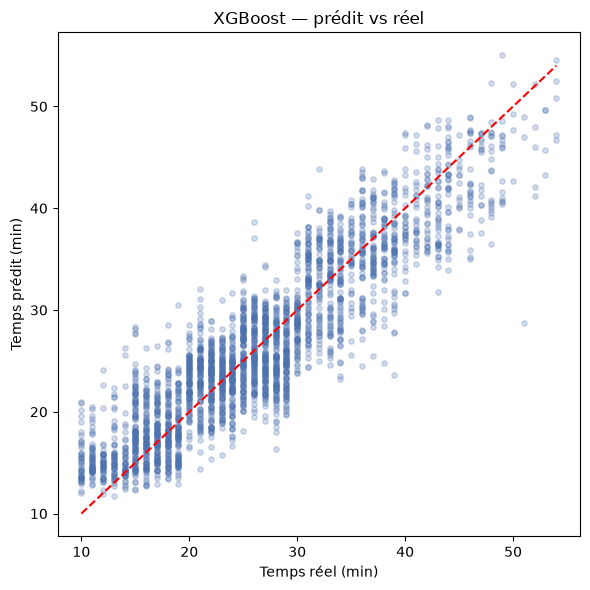

In [5]:
best_name = results_df.iloc[0]["model"]
best_pipe = fitted_pipes[best_name]
preds = best_pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
sample_idx = np.random.RandomState(42).choice(len(y_test), 3000, replace=False)
ax.scatter(y_test.values[sample_idx], preds[sample_idx], alpha=0.25, s=15, color="#4C72B0")
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, "r--", lw=1.5)
ax.set_xlabel("Temps réel (min)")
ax.set_ylabel("Temps prédit (min)")
ax.set_title(f"{best_name} — prédit vs réel")
plt.tight_layout()
plt.show()

## 6. Résidus

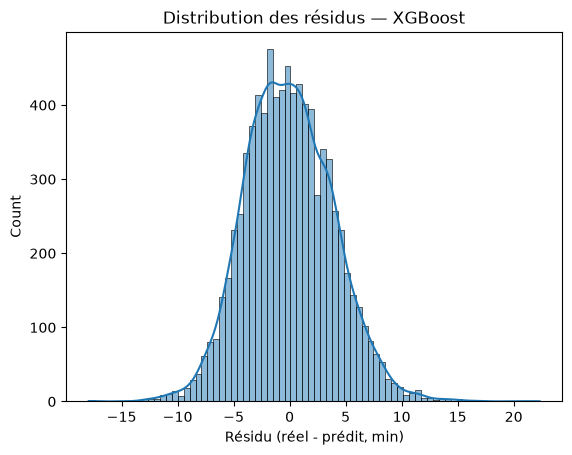

In [6]:
residuals = y_test.values - preds
sns.histplot(residuals, kde=True)
plt.xlabel("Résidu (réel - prédit, min)")
plt.title(f"Distribution des résidus — {best_name}")
plt.show()

## 7. Importance des variables (permutation)

`RandomForestRegressor` expose `feature_importances_` nativement, mais la permutation importance donne un résultat comparable entre modèles et directement lisible par variable brute (avant encodage).

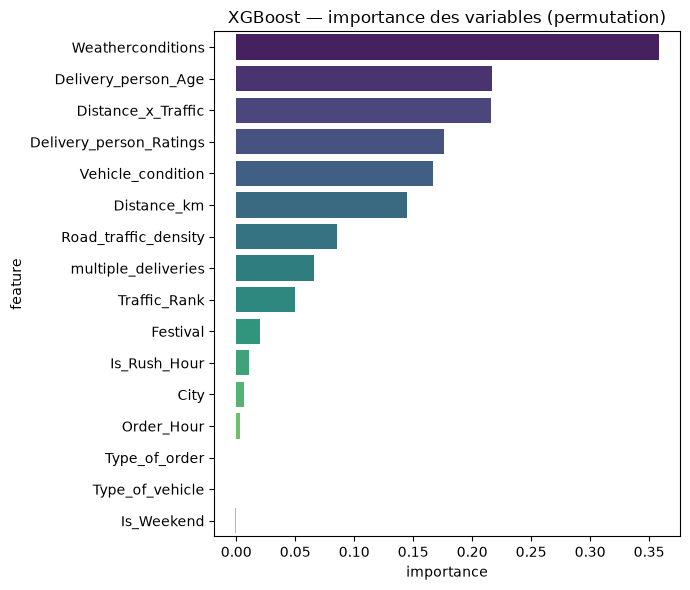

,feature,importance
0,Weatherconditions,0.358219
6,Delivery_person_Age,0.216798
15,Distance_x_Traffic,0.215620
7,Delivery_person_Ratings,0.175807
8,Vehicle_condition,0.166460
10,Distance_km,0.145069
1,Road_traffic_density,0.085794
9,multiple_deliveries,0.065497
14,Traffic_Rank,0.049777
4,Festival,0.019844


In [7]:
result = permutation_importance(best_pipe, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)

imp_df = (
    pd.DataFrame({"feature": X_test.columns, "importance": result.importances_mean})
    .sort_values("importance", ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 6))
sns.barplot(data=imp_df, x="importance", y="feature", hue="feature", legend=False, ax=ax, palette="viridis")
ax.set_title(f"{best_name} — importance des variables (permutation)")
plt.tight_layout()
plt.show()

imp_df

## 8. Sauvegarde du meilleur pipeline (avant tuning)

In [8]:
from pathlib import Path
Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)
joblib.dump(best_pipe, MODEL_DIR / f"{best_name.lower()}_baseline_pipeline.joblib")
print("Sauvegardé :", MODEL_DIR / f"{best_name.lower()}_baseline_pipeline.joblib")

Sauvegardé : C:\Users\Elkerymy-Mohamed\Study-DevAI\DeliveryETA\models\xgboost_baseline_pipeline.joblib


## 9. Résumé

4 modèles comparés sur les mêmes données. RandomForest et XGBoost dominent nettement (R² ≈ 0.82) devant GradientBoosting (0.76) et LinearRegression (0.58). **XGBoost retenu pour le tuning** du fait de sa vitesse d'entraînement, à performance quasi identique. La variable d'interaction `Distance_x_Traffic` créée en EDA figure parmi les plus importantes du modèle.